In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson, uniform, norm, expon, probplot
from math import comb

# Part I Cooling-unit failures: a finite random variable

Verify that the table is a valid PMF, state the support, and distinguish the random variable 
x from an observed value X.

In [6]:
x = np.array([0,1,2,3,4])
p = np.array([0.58, 0.26, 0.10, 0.04, 0.02])

print(f"Sum of probabilities equals 1: {np.isclose(p.sum(), 1)}")
print(f"All probabilities are non-negative: {(p >= 0).all()}")

Sum of probabilities equals 1: True
All probabilities are non-negative: True


In [7]:
df = pd.DataFrame({
  "x" : x,
  "p_X": p
})

#CDF
df["F_X"] = df["p_X"].cumsum()
display(df)

print(
  f"P (X = 2): {p[x == 2].sum()}\n"
  f"P (X <= 1): {p[x <= 1].sum()}\n"
  f"P (1 < X <= 3): {p[(x > 1) & (x <= 3)].sum()}"
  )

,x,p_X,F_X
0,0,0.58,0.58
1,1,0.26,0.84
2,2,0.10,0.94
3,3,0.04,0.98
4,4,0.02,1.00


P (X = 2): 0.1
P (X <= 1): 0.84
P (1 < X <= 3): 0.14


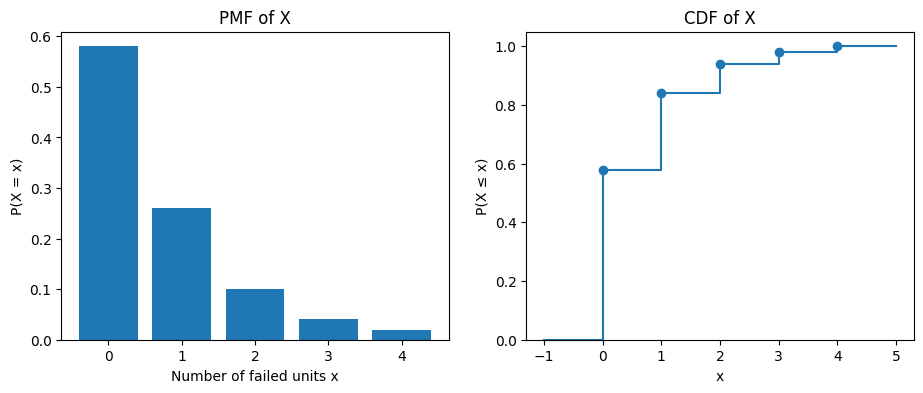

In [8]:
x = np.array([0, 1, 2, 3, 4])
p = np.array([0.58, 0.26, 0.10, 0.04, 0.02])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(x, p)
ax1.set(title="PMF of X", xlabel="Number of failed units x", ylabel="P(X = x)")

xs = np.r_[-1, x, 5]
Fs = np.r_[0, np.cumsum(p), 1]
ax2.step(xs, Fs, where="post")
ax2.scatter(x, np.cumsum(p), zorder=3)
ax2.set(title="CDF of X", xlabel="x", ylabel="P(X ≤ x)", ylim=(0, 1.05))
plt.show()

In the PMF, the bar height at x is the probability that exactly x units fail in a week. For example, the bar at 0 has height 0.58, so there's a 58% chance no unit fails.

In the CDF, the height at x is the probability that at most x units fail: 0.58, 0.84, 0.94, 0.98, 1.00. For example, F(1) = 0.84 means there's an 84% chance of one failure or fewer. The CDF stays flat between integers because X can't take values like 1.5, and the size of each jump equals the PMF bar at that point (the jump at 2 is 0.94 − 0.84 = 0.10).

In [9]:
E = np.sum(x * p)
Var = np.sum((x - E)**2 * p)
SD = np.sqrt(Var)
print(f"E[X] = {E:.4f}, Var(X) = {Var:.4f}, SD(X) = {SD:.4f}")

E[X] = 0.6600, Var(X) = 0.9044, SD(X) = 0.9510


# Part II Repeated-event count models
A project expects 30 deliveries. Each is modelled as late with probability 0.12 independently of the others. Let "B" be the number of late deliveries.

Justify B ~ Bin(30, 0.12). Identify the Bernoulli trial and discuss fixed n, constant p, independence, and one
realistic violation.

**a. Justifying the model**

This model only holds if:

- **Fixed $n$:** the project has exactly 30 deliveries, so the number of trials is known beforehand.
- **Constant $p$:** every delivery has the same 12% chance of being late.
- **Independence:** one delivery being late does not change the chance that another is late.

A realistic violation is independence. If several deliveries come from the same supplier, or go through the same port or the same bad weather, one late delivery makes the others more likely to be late too. The late deliveries then come in groups/chunks, and the real spread of $B$ would be larger than the binomial says.

In [10]:
n, p = 30, 0.12

p_b3 = binom.pmf(3, n, p)
p_b_le4 = binom.cdf(4, n, p)
p_b_ge5 = binom.sf(4, n, p)

print(f"P(B = 3)  = {p_b3:.4f}")
print(f"P(B <= 4) = {p_b_le4:.4f}")
print(f"P(B >= 5) = {p_b_ge5:.4f}")
print(f"P(B <= 4) + P(B >= 5) = {p_b_le4 + p_b_ge5:.4f}")

# same P(B = 3) but formula written out
manual = comb(n, 3) * p**3 * (1 - p)**(n - 3)
print(f"\nC(30, 3) = {comb(n, 3)}")
print(f"P(B = 3) by formula = {manual:.4f}")

P(B = 3)  = 0.2224
P(B <= 4) = 0.7118
P(B >= 5) = 0.2882
P(B <= 4) + P(B >= 5) = 1.0000

C(30, 3) = 4060
P(B = 3) by formula = 0.2224


**b. Probabilities**

- P(B = 3) = 0.2224, so about a 22% chance of exactly 3 late deliveries
- P(B ≤ 4) = 0.7118, so about a 71% chance of at most 4 late deliveries
- P(B ≥ 5) = 0.2882, so about a 29% chance of 5 or more late deliveries

The formula for exactly 3 late deliveries is:

P(B = 3) = C(30, 3) × 0.12³ × 0.88²⁷

C(30, 3) = 4060 is the number of ways to choose which 3 of the 30 deliveries are the late ones. Each of those choices has the same probability, 0.12³ × 0.88²⁷ (3 late, 27 on time), so I multiply the two. The result matches the SciPy value.

For the upper tail, `binom.sf(k, n, p)` gives P(B > k), not P(B ≥ k). B only takes whole numbers, so B ≥ 5 is the same as B > 4, which means I use `sf(4)`. Using `sf(5)` would give P(B ≥ 6) instead. As a check, 0.7118 + 0.2882 = 1.

**c. Mean and standard deviation**

In [11]:
mean_b = n * p
sd_b = np.sqrt(n * p * (1 - p))

print(f"E[B] = {mean_b:.2f}")
print(f"SD(B) = {sd_b:.4f}")
print(f"SciPy check: {binom.mean(n, p):.2f}, {binom.std(n, p):.4f}")

E[B] = 3.60
SD(B) = 1.7799
SciPy check: 3.60, 1.7799


- Mean = n × p = 30 × 0.12 = 3.6
- SD = √(n × p × (1 − p)) = √(30 × 0.12 × 0.88) = 1.78

On average, 3.6 of the 30 deliveries are late. The standard deviation of about 1.8 shows how far the count usually is from that average, so 2 to 5 late deliveries would not be surprising. This fits with P(B ≥ 5) being 29%.

## Production stoppages: Poisson

**a. Model for one shift**

Y is the number of short stoppages in one 8-hour shift. Stoppages happen at an average rate of 1.6 per shift, so Y ~ Poisson(1.6).

- Parameter: lambda = 1.6, the average number of stoppages per shift
- Support: y = 0, 1, 2, ... with no upper limit
- Mean: E[Y] = 1.6
- Variance: Var(Y) = 1.6 too, since mean and variance are always equal for Poisson

In [12]:
lam = 1.6

p_y0 = poisson.pmf(0, lam)
p_y_ge3 = poisson.sf(2, lam)

print(f"E[Y] = {poisson.mean(lam):.2f}, Var(Y) = {poisson.var(lam):.2f}")
print(f"P(Y = 0)  = {p_y0:.4f}")
print(f"P(Y >= 3) = {p_y_ge3:.4f}")

E[Y] = 1.60, Var(Y) = 1.60
P(Y = 0)  = 0.2019
P(Y >= 3) = 0.2166


- P(Y = 0) = 0.2019, so about a 20% chance of no stoppages in a shift
- P(Y ≥ 3) = 0.2166, so about a 22% chance of 3 or more stoppages in a shift

Same rule as before: Y ≥ 3 is the same as Y > 2, so we use `poisson.sf(2, lam)`.

In [13]:
lam_24 = lam * 3   # 24 hours = 3 shifts of 8 hours

p_z_ge3 = poisson.sf(2, lam_24)

print(f"expected stoppages in 24 h = {lam_24:.1f}")
print(f"P(at least 3 in 24 h) = {p_z_ge3:.4f}")

expected stoppages in 24 h = 4.8
P(at least 3 in 24 h) = 0.8575


**b. Scaling to 24 hours**

24 hours is three 8-hour shifts, so the average count also multiplies by 3: lambda = 1.6 × 3 = 4.8. Let Z be the number of stoppages in 24 hours, so Z ~ Poisson(4.8).

P(Z ≥ 3) = 0.8575, so about an 86% chance of at least 3 stoppages somewhere across the day. That's much higher than for one shift, just because there's three times as much time for stoppages to happen.

This only works under two assumptions:

- Stable rate: the 1.6-per-shift rate has to hold for all three shifts. If, say, the night shift is worse than the day shift, multiplying by 3 would be wrong.
- Independent events: one stoppage should not make another more likely right after it. If stoppages tend to cause more stoppages, they would cluster and this model would understate how often bad days happen.

# Part III Uniform and normal models

## Sensor polling delay: uniform

A monitoring device polls a sensor once every 12 seconds. An event is assumed to occur at a random point in the cycle, so the delay $D$ until the next poll is modelled as

$D \sim \text{Uniform}(0, 12)$.

**a. SciPy model, PDF, and CDF**

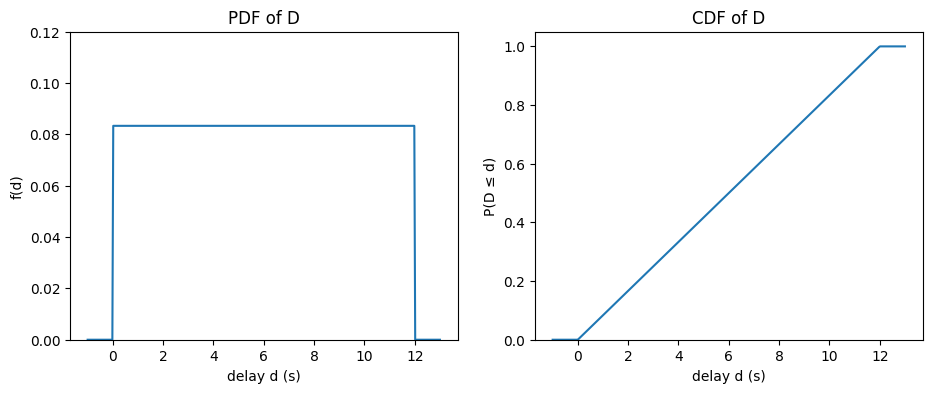

In [14]:
low, high = 0, 12
D = uniform(loc=low, scale=high - low)  # scale is the WIDTH of the interval, not the right endpoint

d = np.linspace(-1, 13, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(d, D.pdf(d))
ax1.set(title="PDF of D", xlabel="delay d (s)", ylabel="f(d)", ylim=(0, 0.12))

ax2.plot(d, D.cdf(d))
ax2.set(title="CDF of D", xlabel="delay d (s)", ylabel="P(D ≤ d)", ylim=(0, 1.05))
plt.show()

SciPy's `uniform` is parameterised by `loc` (the left endpoint) and `scale` (the *width* of the interval), so `Uniform(0, 12)` needs `loc=0, scale=12` — not `scale=12` mistaken for the right endpoint when `loc` isn't 0.

The support is $[0, 12]$: the next poll always falls somewhere inside the 12-second cycle, so $D$ can never be negative or exceed 12. Inside that range the density is flat at $f(d) = 1/12 \approx 0.083$, since every instant in the cycle is equally likely to be when the event occurs, that's what "uniform" means here. Because $D$ is continuous, a single exact value has zero width under a flat density, so $P(D = d) = 0$ for every $d$; probability only accumulates over an interval, which is why we read probabilities off the CDF (or integrate the PDF over a range) rather than plugging a point into the PDF.

**b. Probabilities, mean, SD, and the 95th percentile**

In [15]:
p_d_le3 = D.cdf(3)
p_4_9 = D.cdf(9) - D.cdf(4)
p_d_gt10 = D.sf(10)
mean_d = D.mean()
sd_d = D.std()
pct95_d = D.ppf(0.95)

print(f"P(D <= 3)    = {p_d_le3:.4f}")
print(f"P(4 < D < 9) = {p_4_9:.4f}")
print(f"P(D > 10)    = {p_d_gt10:.4f}")
print(f"mean = {mean_d:.4f}, SD = {sd_d:.4f}")
print(f"95th percentile = {pct95_d:.4f}")

P(D <= 3)    = 0.2500
P(4 < D < 9) = 0.4167
P(D > 10)    = 0.1667
mean = 6.0000, SD = 3.4641
95th percentile = 11.4000


- P(D ≤ 3) = 0.2500 — a 25% chance the next poll comes within 3 seconds, i.e. 3/12.
- P(4 < D < 9) = 0.4167 — the window is 5 seconds wide, and 5/12 ≈ 0.4167.
- P(D > 10) = 0.1667 — only the last 2 seconds of the cycle lie beyond 10, and 2/12 ≈ 0.1667.

For a uniform variable every probability is just "length of the interval ÷ 12", which is exactly what these three numbers confirm.

The mean is (0 + 12)/2 = 6 s, the midpoint of the cycle, and the SD is 12/√12 ≈ 3.46 s. The 95th percentile is 11.4 s: 95% of polls occur within the first 11.4 seconds of the cycle, leaving only the last 0.6 seconds (5% of 12) beyond it.

## Concrete strength: normal working model

The file `assignment02_concrete_strength.csv` contains 160 compressive-strength measurements. We treat the parameters that generated the data as unknown and estimate them from the sample.

**a. Descriptive statistics and fitted normal model**

In [16]:
concrete = pd.read_csv("data/assignment02_concrete_strength.csv")
strength = concrete["strength_mpa"]

n_c = len(strength)
mean_hat = strength.mean()
median_hat = strength.median()
sd_hat = strength.std(ddof=1)  # sample SD, n-1 denominator

print(f"n = {n_c}")
print(f"mean      = {mean_hat:.4f}")
print(f"median    = {median_hat:.4f}")
print(f"sample SD = {sd_hat:.4f}")

concrete_model = norm(loc=mean_hat, scale=sd_hat)
print(f"\nFitted model: N(mu_hat={mean_hat:.4f}, sigma_hat^2={sd_hat**2:.4f})")

n = 160
mean      = 42.4942
median    = 42.3800
sample SD = 4.3429

Fitted model: N(mu_hat=42.4942, sigma_hat^2=18.8609)


With n = 160, the sample mean is 42.49 MPa and the median is 42.38 MPa close together, which already hints the distribution isn't badly skewed. The sample standard deviation is 4.34 MPa.

SciPy's `norm` takes `loc` for μ and `scale` for σ, the standard deviation not σ², the variance. The normal PDF's exponent is built from `((x - μ) / σ)²`, so SciPy expects the same σ it will square internally when it evaluates that ratio; that's the quantity `scale` represents. σ² is also in squared MPa², a different unit than the data itself, so it can't stand in for a location-scale parameter measured in MPa. Passing σ̂² ≈ 18.86 as `scale` instead of σ̂ ≈ 4.34 would tell SciPy the spread is over 4 times wider than it really is.

**b. Histogram, fitted PDF, and QQ-plot**

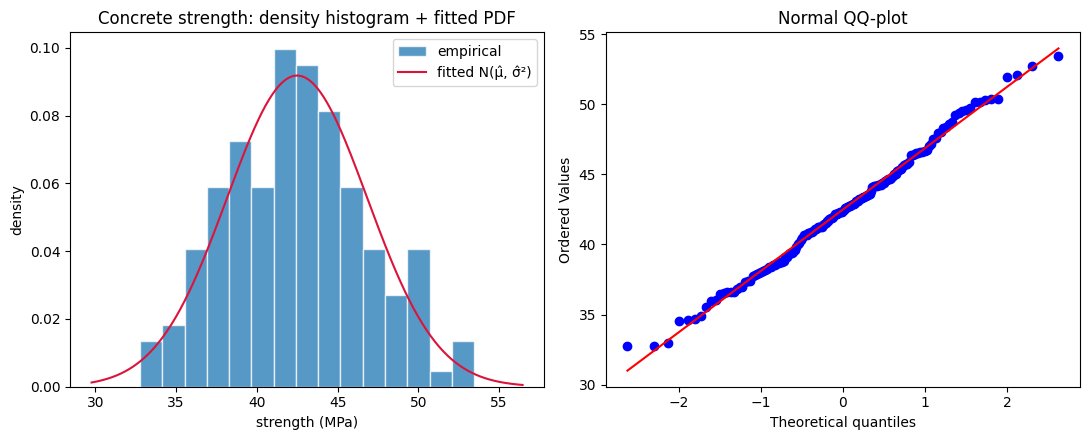

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.hist(strength, bins=15, density=True, edgecolor="white", alpha=0.75, label="empirical")
xs = np.linspace(strength.min() - 3, strength.max() + 3, 400)
ax1.plot(xs, concrete_model.pdf(xs), color="crimson", label="fitted N(μ̂, σ̂²)")
ax1.set(title="Concrete strength: density histogram + fitted PDF", xlabel="strength (MPa)", ylabel="density")
ax1.legend()

probplot(strength, dist="norm", plot=ax2)
ax2.set_title("Normal QQ-plot")

plt.tight_layout()
plt.show()

The histogram is roughly bell-shaped and centred right around the fitted curve, with no strong pull to either side, consistent with the mean and median being nearly equal.

The sample skewness is about 0.14 (close to 0, only a slight lean to the right) and the excess kurtosis is about −0.31, meaning the tails are marginally *lighter* than a normal distribution's rather than heavier. On the QQ-plot this shows up as the points hugging the reference line closely through the middle, with the two ends curving in slightly toward the line instead of flaring away from it, the signature of thin tails, not of outliers. No single point sits dramatically off the line, so there's no evidence of an unusual observation. Overall, the normal working model looks adequate for this data.

**c. Probabilities, percentile, and z-score**

In [18]:
p_lt35 = concrete_model.cdf(35)
p_38_46 = concrete_model.cdf(46) - concrete_model.cdf(38)
pct95_conc = concrete_model.ppf(0.95)
z_35 = (35 - mean_hat) / sd_hat

emp_lt35 = (strength < 35).mean()
emp_38_46 = ((strength > 38) & (strength < 46)).mean()

print(f"P(X < 35)      = {p_lt35:.4f}  (empirical: {emp_lt35:.4f})")
print(f"P(38 < X < 46) = {p_38_46:.4f}  (empirical: {emp_38_46:.4f})")
print(f"95th percentile   = {pct95_conc:.4f}")
print(f"z-score of 35 MPa = {z_35:.4f}")

P(X < 35)      = 0.0422  (empirical: 0.0437)
P(38 < X < 46) = 0.6399  (empirical: 0.6375)
95th percentile   = 49.6376
z-score of 35 MPa = -1.7256


P(X < 35) ≈ 0.0422 under the fitted model, close to the empirical proportion of 0.0437 (exactly 7 of the 160 specimens fall below 35 MPa). P(38 < X < 46) ≈ 0.6399 versus an empirical 0.6375, both pairs agree to within about a percentage point, another sign that the normal model fits this data reasonably well.

The 95th percentile is about 49.64 MPa, so only 5% of specimens are expected to exceed that strength. The z-score of 35 MPa is about −1.73, meaning 35 MPa sits roughly 1.73 standard deviations below the mean, a low but not extreme reading under this model.

# Part IV Service restoration: an exponential working model

The file `assignment02_service_repairs.csv` contains 180 restoration times from independent service incidents. We treat the rate as unknown and estimate it from the sample.

**a. Descriptive statistics and shape**

n = 180
mean      = 69.7986
median    = 49.3450
sample SD = 67.4332
min = 1.11, max = 410.66


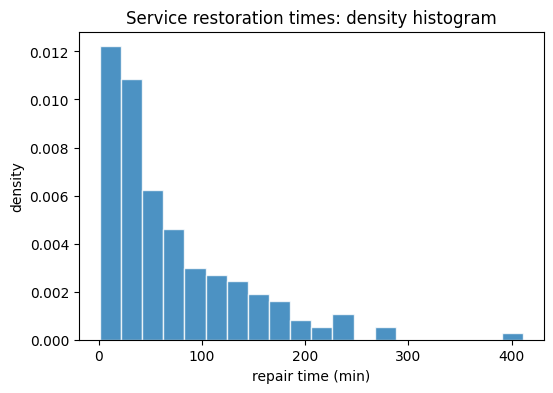

In [29]:
repairs = pd.read_csv("data/assignment02_service_repairs.csv")
t = repairs["repair_time_min"]

n_t = len(t)
mean_t = t.mean()
median_t = t.median()
sd_t = t.std(ddof=1)
min_t = t.min()
max_t = t.max()

print(f"n = {n_t}")
print(f"mean      = {mean_t:.4f}")
print(f"median    = {median_t:.4f}")
print(f"sample SD = {sd_t:.4f}")
print(f"min = {min_t:.2f}, max = {max_t:.2f}")

plt.figure(figsize=(6, 4))
plt.hist(t, bins=20, density=True, edgecolor="white", alpha=0.8)
plt.title("Service restoration times: density histogram")
plt.xlabel("repair time (min)")
plt.ylabel("density")
plt.show()

With n = 180, the mean restoration time is 69.80 minutes, well above the median of 49.35 minutes, the mean sitting above the median like this is a classic sign of right skew. The sample SD (67.43 min) is almost as large as the mean itself, and times range from about 1.1 to 410.7 minutes.

The histogram confirms it: a tall bar of short repairs near zero, then a long, thinning right tail of occasional long ones. Many short waits, a few very long ones, and a mean roughly equal to the SD, that shape is exactly what an exponential distribution looks like.

**b. Fitted exponential model**

In [30]:
lam_hat = 1 / mean_t
repair_model = expon(scale=1 / lam_hat)

print(f"lambda_hat = {lam_hat:.5f} restorations per minute")
print(f"fitted mean     = {repair_model.mean():.4f}")
print(f"fitted variance = {repair_model.var():.4f}")
print(f"SciPy scale (1/lambda_hat) = {1 / lam_hat:.4f}")

lambda_hat = 0.01433 restorations per minute
fitted mean     = 69.7986
fitted variance = 4871.8461
SciPy scale (1/lambda_hat) = 69.7986


The rate is estimated as λ̂ = 1/x̄ ≈ 0.0143 restorations per minute. SciPy's `expon` is parameterised by `scale`, which stands for 1/λ rather than λ itself, so we pass `scale=1/lambda_hat` (≈ 69.80) instead of `lambda_hat` directly. The fitted mean comes out to exactly 1/λ̂ = 69.80 min, it has to, since that's how λ̂ was chosen and the fitted variance is 1/λ̂² ≈ 4871.8 min². For an exponential distribution the SD always equals the mean, so a mean of ~70 minutes implies an SD of ~70 minutes too, matching what we saw empirically.

**c. Empirical vs. fitted CDF**

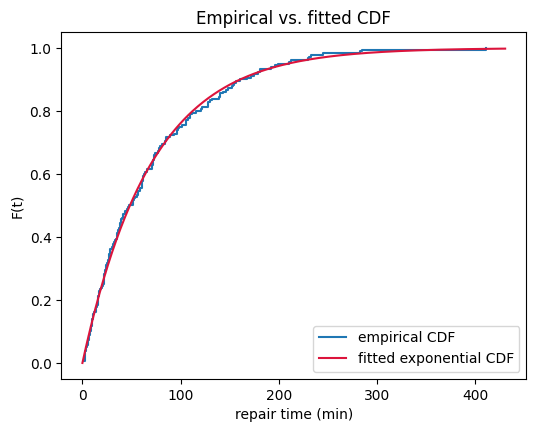

In [31]:
t_sorted = np.sort(t)
ecdf = np.arange(1, n_t + 1) / n_t

plt.figure(figsize=(6, 4.5))
plt.step(t_sorted, ecdf, where="post", label="empirical CDF")
xs = np.linspace(0, t.max() + 20, 400)
plt.plot(xs, repair_model.cdf(xs), color="crimson", label="fitted exponential CDF")
plt.title("Empirical vs. fitted CDF")
plt.xlabel("repair time (min)")
plt.ylabel("F(t)")
plt.legend()
plt.show()

The empirical and fitted CDFs track each other closely across almost the whole range, which supports the exponential model: it captures the steep early rise (lots of quick repairs finishing in the first hour or so) as well as the long, thin tail of the slower ones. There's some minor wiggle where the empirical step function crosses back and forth over the fitted curve, but no large, systematic gap between the two.

The main limitation is the constant-rate assumption baked into the exponential: it says a repair is just as likely to finish in the next minute whether it just started or has already run for two hours, with no aging or wear-in effect, and it forces the density to peak at t = 0. Real repairs probably have a small minimum handling time before the fastest ones could possibly finish, which the exponential can't represent, but as a working model it captures the overall shape well.

**d. Probabilities, median, and the 90th percentile**

In [32]:
p_t_lt30 = repair_model.cdf(30)
p_t_gt120 = repair_model.sf(120)
median_t_model = repair_model.median()
pct90_t = repair_model.ppf(0.90)

emp_lt30 = (t < 30).mean()
emp_gt120 = (t > 120).mean()

print(f"P(T < 30)  = {p_t_lt30:.4f}  (empirical: {emp_lt30:.4f})")
print(f"P(T > 120) = {p_t_gt120:.4f}  (empirical: {emp_gt120:.4f})")
print(f"median = {median_t_model:.4f}")
print(f"90th percentile = {pct90_t:.4f}")

P(T < 30)  = 0.3494  (empirical: 0.3611)
P(T > 120) = 0.1792  (empirical: 0.2000)
median = 48.3807
90th percentile = 160.7172


P(T < 30) ≈ 0.3494 under the model, close to the empirical 0.3611, roughly 35–36% of repairs finish within half an hour. P(T > 120) ≈ 0.1792 against an empirical 0.2000, so about a fifth of repairs run past two hours; the model slightly underestimates that long tail, but the two numbers are still in the same range.

The median restoration time is about 48.4 minutes, noticeably below the mean of 69.8 minutes, expected for a right-skewed exponential, since the mean (1/λ) is always larger than the median (ln(2)/λ). The 90th percentile is about 160.7 minutes: 90% of repairs finish within roughly two and a half hours.

**e. Memoryless property: P(T > 150 | T > 60)**

In [33]:
p_cond_ratio = repair_model.sf(150) / repair_model.sf(60)
p_extra_90 = repair_model.sf(90)

print(f"P(T > 150 | T > 60) via ratio of survival probs = {p_cond_ratio:.4f}")
print(f"P(T > 90) (waiting an additional 90 min)         = {p_extra_90:.4f}")

P(T > 150 | T > 60) via ratio of survival probs = 0.2754
P(T > 90) (waiting an additional 90 min)         = 0.2754


Both routes give the same answer, about 0.2754. As a ratio of survival probabilities, P(T > 150 | T > 60) = P(T > 150) / P(T > 60) = S(150)/S(60). Framed as "waiting an additional 90 minutes", it's just P(T > 90), the probability a brand-new repair takes more than 90 minutes from scratch.

The two calculations agree because the exponential distribution is memoryless: given that a repair has already run past the 60-minute mark, the *additional* time it still needs behaves exactly like a fresh repair timer starting at zero, the 60 minutes already spent carry no information about how much longer it will take. That only holds because we assumed a constant restoration rate λ that doesn't change with elapsed time; if repairs became easier to finish the longer they'd run (or harder, e.g. compounding complexity), the two calculations would no longer match.

# Part V AI use and conclusion

## AI-use statement

AI was mainly used for generating plots and rewriting and prettyfying the text. 

## Overall conclusion

Six probability models matched each variable's origin. Support fixed the tool: cooling-unit failures, late deliveries, and stoppages are non-negative integers, so PMFs and sums applied; polling delay, concrete strength, and repair time are continuous, so PDFs and CDFs applied. Mixing these up gives a meaningless number.

Mechanism picked the family. Binomial came from counting successes over fixed, independent, constant-probability trials; Poisson from counting rare events continuously over time; Exponential modelled the waiting time between them, inheriting memorylessness. Normal and Exponential were fitted, working models chosen from the data's shape, not a known mechanism.

Parameterisation was a practical trap: SciPy's norm takes a standard deviation, not variance; expon takes a mean, not a rate; uniform takes a width, not an endpoint. Wrong values still run, just wrong. Graphical checks - histograms, QQ-plots, and empirical-vs-fitted CDFs - justified trusting the fitted models.